In [1]:
import sys
sys.path.append('..')

In [2]:
from src.l1_tools import *

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
df = pd.read_csv("../data/processed/cloudy_sky_mean_profiles.csv")

analog_parallel = df["RCS_04"].values
analog_perpendicular = df["RCS_02"].values
photocounting_parallel = df["RCS_05"].values
photocounting_perpendicular = df["RCS_03"].values

altitude = df["Altitude_m"].values
print(np.shape(altitude))


(4000,)


In [4]:
df = pd.read_csv("../data/processed/molecular_profiles_reference.csv")
AMB_clear = df["AMB_clear"].values
AMB_clear_parallel = df["AMB_clear_parallel"].values
AMB_clear_perpendicular = df["AMB_clear_perpendicular"].values
beta_ray = df["beta_ray"].values
beta_ray_parallel = df["beta_ray_parallel"].values
beta_ray_perpendicular = df["beta_ray_perpendicular"].values


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


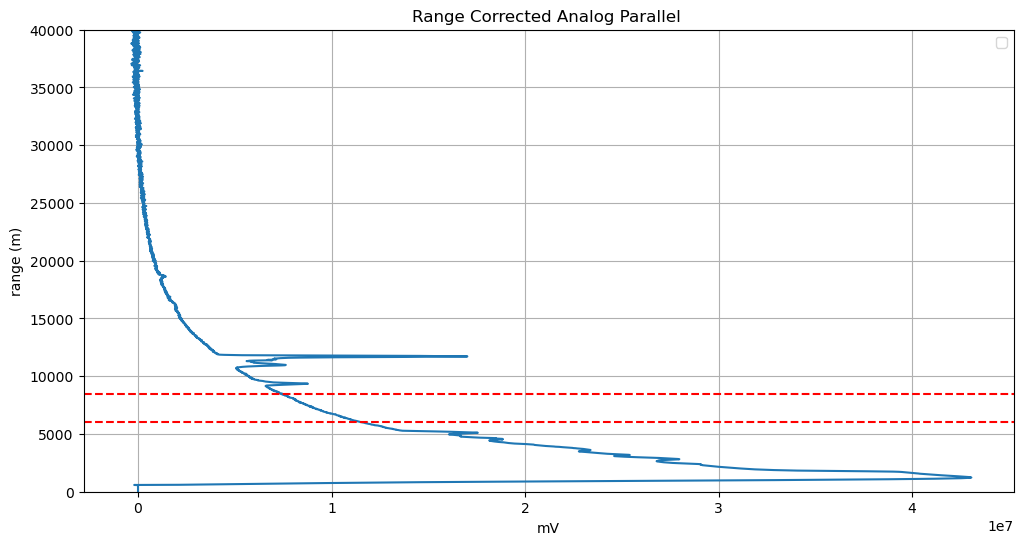

In [5]:
mask_mol =[6000 , 8500]

plt.figure(figsize=(12,6))
plt.title(f"Range Corrected Analog Parallel ")
plt.plot( analog_parallel, altitude)
plt.axhline(y=mask_mol[0], color='r', linestyle='--')
plt.axhline(y=mask_mol[1], color='r', linestyle='--' )

plt.ylim((0, 40000))
plt.grid(True)
plt.xlabel("mV")
plt.ylabel("range (m)")
plt.legend()

In [6]:
depol_mol =0.004


index_altitude_clear = np.where((altitude >= mask_mol[0]) & (altitude <= mask_mol[1]))[0]

P_meas_perp_mol = np.nanmean(analog_perpendicular[index_altitude_clear] , axis=0)
P_meas_par_mol = np.nanmean(analog_parallel[index_altitude_clear] , axis=0)

A = P_meas_perp_mol /(2*P_meas_par_mol)

B = depol_mol/((P_meas_perp_mol / P_meas_par_mol ) - A)
R = (analog_perpendicular/analog_parallel)


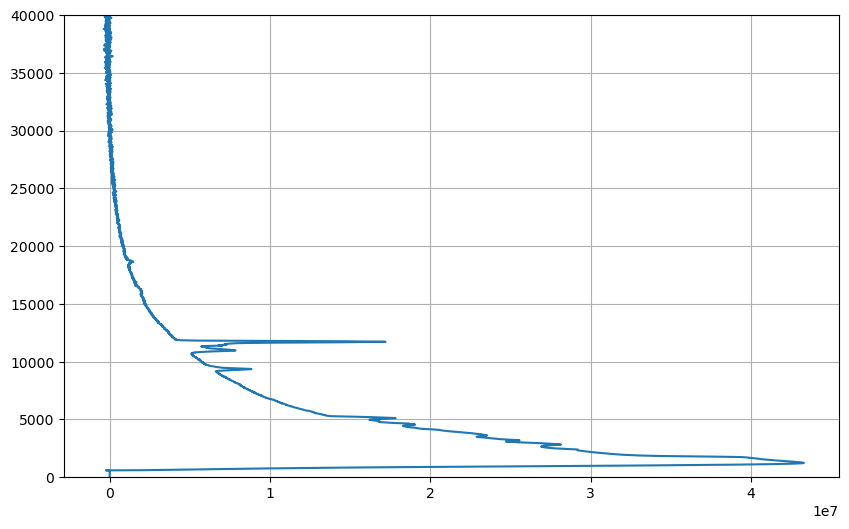

In [7]:
P_total = analog_parallel*(1+B*(R-A))

plt.figure(figsize=(10,6))
plt.plot(P_total , altitude)
plt.ylim(0 , 40000)
plt.grid(True)



In [10]:
K_0_an , delta_0_an =Calibration(P_total , AMB_clear , altitude ,  mask_mol , mask_mol , visual=False ) 
K_analog, delta_analog, result = optimize(P_total, AMB_clear, altitude,[mask_mol ],K_0_an, delta_0_an ,  method='Nelder-Mead')


ATB_analog = K_analog * ( P_total - delta_analog  ) 
print("initiale K:", K_0_an, "delta:", delta_0_an)
print("optimized K:", K_analog, "delta:", delta_analog)

initiale K: 2.0857865945570523e-13 delta: -663579.578409592
optimized K: 2.081967333920942e-13 delta: -290497.3594707283


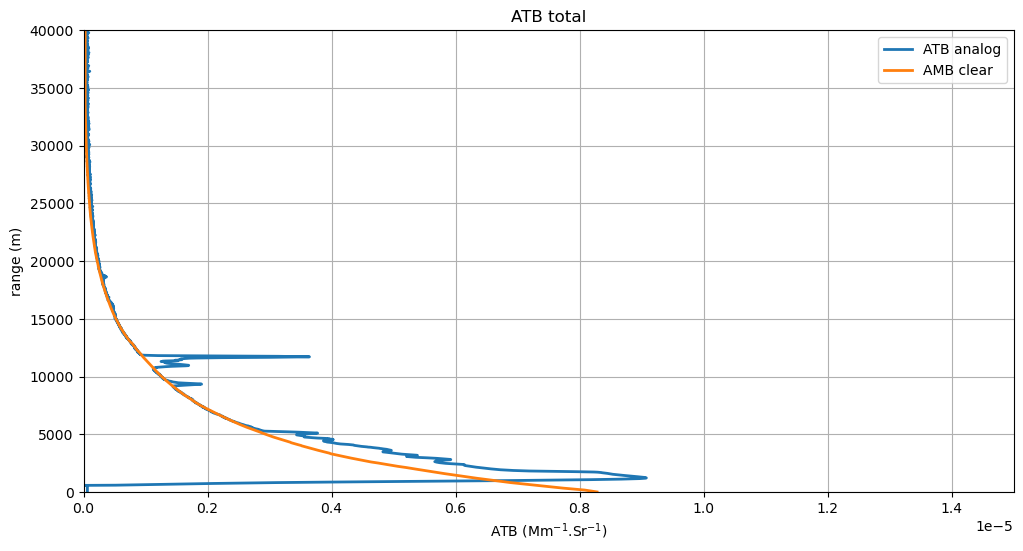

In [17]:
plt.figure(figsize=(12,6))
plt.title("ATB total")
plt.plot(ATB_analog , altitude , linewidth = 2 , label="ATB analog")
plt.plot(AMB_clear , altitude , linewidth = 2 , label="AMB clear")
plt.ylim(0 , 40000)
plt.xlim((0, 1.5e-5))
plt.xlabel("ATB (Mm$^{-1}$.Sr$^{-1}$)")
plt.ylabel("range (m)")
plt.grid(True)
plt.legend()